In [5]:
import warnings
warnings.simplefilter('ignore') #ignore matplotlib complaints about multiple imports

import numpy as np
import pandas as pd
import timecorr as tc
import hypertools as hyp
import supereeg as se
from matplotlib import pyplot as plt
import seaborn as sns
import os
from glob import glob as lsdir
from scipy.io import loadmat as load
import numba
import nltools as nl
import nibabel as nib
from nilearn.input_data import NiftiMasker
from scipy.spatial.distance import pdist, cdist, squareform
from collections import deque

%matplotlib inline

In [6]:
datadir = os.path.join(os.getenv('HOME'), 'data', 'fMRI', 'dffr')
nii_files = lsdir(os.path.join(datadir, '*.nii'))
regressor_files = lsdir(os.path.join(datadir, 'regmats', '*.mat'))

In [7]:
def cluster_maxdist(dists, maxdist):
    '''
    returns cluster labels for observations such that each observation
    in a group is within maxdist units of at least one other observation
    in the same group
    '''
    
    assert np.all(dists >= 0), 'All distances must be non-negative'
    assert maxdist > 0, 'Maximum distance must be positive'
    
    labels = np.zeros(dists.shape[0])
    
    group = 1
    i = 0
    while i < dists.shape[0]:
        #if i is in a group already, continue
        if labels[i] != 0:
            i += 1
            continue
        
        #go through all existing groups and check if i
        #is within maxdist units of any element of an existing group
        for g in (np.arange(group) + 1):
            next_inds = labels == g
            next_dists = dists[next_inds, i]
            if np.any(next_dists <= maxdist):
                labels[i] = g
                break
        
        #if i matched a prior group, continue
        if labels[i] != 0:
            continue
        
        #if we get here, i is not within maxdist units of any prior
        #group.  so we need a new group.  assign i, and any elements
        #within maxdist units of i, to the new group
        labels[i] = group
        
        next_dists = dists[i, :]
        labels[next_dists <= maxdist] = group
        
        #print(f'{np.sum(next_dists <= maxdist)} new observations assigned')
        
        #find the next unassigned observation and increment the group number
        if not np.any(labels == 0):
            break
        else:
            i = np.min(np.nonzero(labels))
            group += 1
    return labels - 1

In [57]:
def get_neurosynth_mask(maxdist=6):
    mask_fname = 'Neurosynth Parcellation_0.nii.gz'
    if not os.path.exists(mask_fname):
        print('Downloading mask...')
        !wget http://neurovault.org/media/images/2099/Neurosynth%20Parcellation_0.nii.gz
    print('Loading mask...')
    nii = nib.load(mask_fname)
    
    print('Converting Nifti file to Brain object...')
    bo = se.Brain(nii, filter=None)
    
    print('Extracting data from Brain object...')
    labels = bo.data
    
    
    clusters = np.unique(labels)
    clusters = clusters[clusters > 0]
    next_free_label = np.round(np.max(clusters) + 1)
    
    for i in clusters:
        print(f'next free label: {next_free_label}')
        next_inds = np.where(np.isclose(labels, i))[1]
        
        #print(f'Sanity check 1 passed: {np.all(np.isclose(labels.T.iloc[next_inds], i))}')
        
        print(f'number of observations in cluster {np.round(i)}: {len(next_inds)}')
        next_locs = bo.get_locs().iloc[next_inds]
        
        next_sub_clusters = cluster_maxdist(squareform(pdist(next_locs)), maxdist)
        print(f'{len(np.unique(next_sub_clusters))} sub-cluster(s) found')
        next_sub_clusters[next_sub_clusters > 0] = next_sub_clusters[next_sub_clusters > 0] + next_free_label - 1
        next_sub_clusters[next_sub_clusters == 0] = np.round(i)
        
        print(f'next sub-clusters: {np.unique(next_sub_clusters)} (shape: {next_sub_clusters.shape})')
        
        labels.T.iloc[next_inds] = np.round(next_sub_clusters)[:, np.newaxis]
        #print(f'Sanity check 2 passed: {np.all(labels.T.iloc[next_inds] in np.unique(np.round(next_sub_clusters)))}')
                
        next_free_label = np.round(np.max(labels.values) + 1)
    
    bo.data = labels
    return bo

In [58]:
labels = get_neurosynth_mask()

Loading mask...
Converting Nifti file to Brain object...
Extracting data from Brain object...
next free label: 51.0
number of observations in cluster 1.0: 1746
1 sub-cluster(s) found
next sub-clusters: [1.] (shape: (1746,))
next free label: 51.0
number of observations in cluster 2.0: 2929
5 sub-cluster(s) found
next sub-clusters: [ 2. 51. 52. 53. 54.] (shape: (2929,))
next free label: 55.0
number of observations in cluster 3.0: 6376
12 sub-cluster(s) found
next sub-clusters: [ 3. 55. 56. 57. 58. 59. 60. 61. 62. 63. 64. 65.] (shape: (6376,))
next free label: 66.0
number of observations in cluster 4.0: 2949
4 sub-cluster(s) found
next sub-clusters: [ 4. 66. 67. 68.] (shape: (2949,))
next free label: 69.0
number of observations in cluster 5.0: 2786
4 sub-cluster(s) found
next sub-clusters: [ 5. 69. 70. 71.] (shape: (2786,))
next free label: 72.0
number of observations in cluster 6.0: 3383
3 sub-cluster(s) found
next sub-clusters: [ 6. 72. 73.] (shape: (3383,))
next free label: 74.0
number

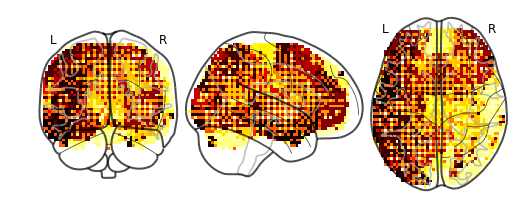

In [64]:
se.Nifti(labels).plot_glass_brain()

In [34]:
mask.tolist()

[54792,
 54793,
 54794,
 54795,
 54809,
 54810,
 54811,
 54812,
 54813,
 54828,
 54829,
 54830,
 54831,
 54832,
 54846,
 54847,
 54848,
 54849,
 54850,
 54865,
 54866,
 54867,
 54868,
 54869,
 54889,
 54890,
 54891,
 54892,
 54912,
 54913,
 54914,
 54934,
 57136,
 57137,
 57138,
 57173,
 57174,
 57175,
 57176,
 57177,
 57207,
 57208,
 57209,
 57210,
 57211,
 57212,
 57237,
 57238,
 57239,
 57240,
 57241,
 57242,
 57243,
 57244,
 57258,
 57259,
 57260,
 57261,
 57262,
 57263,
 57264,
 57265,
 57266,
 57280,
 57281,
 57282,
 57283,
 57284,
 57285,
 57286,
 57287,
 57288,
 57289,
 57302,
 57303,
 57304,
 57305,
 57306,
 57307,
 57308,
 57309,
 57310,
 57311,
 57332,
 57333,
 57334,
 57335,
 57336,
 57337,
 57338,
 57339,
 57340,
 57367,
 57368,
 57369,
 57370,
 57371,
 57372,
 57373,
 57374,
 57402,
 57403,
 57404,
 57405,
 57406,
 57407,
 57408,
 57409,
 57435,
 57436,
 57437,
 57438,
 57439,
 57440,
 57441,
 57467,
 57468,
 59703,
 59704,
 59739,
 59740,
 59741,
 59774,
 59775,
 59776,


In [254]:
mask_fname = 'Neurosynth Parcellation_0.nii.gz'
if not os.path.exists(mask_fname):
    !wget http://neurovault.org/media/images/2099/Neurosynth%20Parcellation_0.nii.gz
nii = nib.load(mask_fname)

In [256]:
bo = se.Brain(nii, filter=None)

In [260]:
np.unique(bo.get_data())

array([ 1.        ,  2.        ,  3.        ,  4.        ,  5.        ,
        6.00000001,  6.99999999,  8.        ,  9.        , 10.        ,
       11.        , 12.        , 13.        , 14.        , 15.        ,
       16.        , 17.        , 18.00000001, 18.99999999, 20.        ,
       21.        , 22.        , 23.        , 24.        , 25.        ,
       26.        , 27.        , 28.        , 29.        , 30.        ,
       31.00000001, 31.99999999, 33.        , 34.        , 35.        ,
       36.        , 37.        , 38.        , 39.        , 40.        ,
       41.        , 42.        , 43.00000001, 43.99999999, 45.        ,
       46.        , 47.        , 48.        , 49.        , 49.99999999])

In [201]:
mask = nl.Brain_Data('http://neurovault.org/media/images/2099/Neurosynth%20Parcellation_0.nii.gz')
nii = mask.to_nifti()
bo = se.Brain(nii, filter=None)

In [250]:
bo2nii = se.Nifti('http://neurovault.org/media/images/2099/Neurosynth%20Parcellation_0.nii.gz')

FileNotFoundError: [Errno 2] No such file or directory: 'http://neurovault.org/media/images/2099/Neurosynth%20Parcellation_0.nii.gz'

In [249]:
se.Brain()

AttributeError: 'Nifti' object has no attribute '_data_cache'

In [235]:
labels = np.round(bo.get_data())

KeyboardInterrupt: 

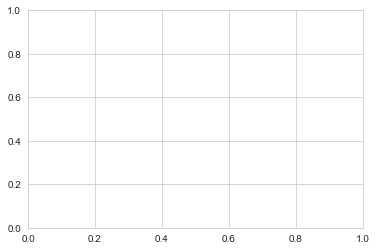

In [247]:
plt.plot(np.argsort(labels))

In [236]:
maxdist = 6

In [244]:
clusters = np.unique(labels)
clusters = clusters[clusters > 0]
next_free_label = np.max(clusters) + 1

for i in clusters:
    print(f'next free label: {next_free_label}')
    next_inds = np.where(np.isclose(labels, i))[1]
    next_locs = bo.get_locs().iloc[next_inds]

    next_sub_clusters = cluster_maxdist(squareform(pdist(next_locs)), maxdist)
    next_sub_clusters[next_sub_clusters > 0] = next_sub_clusters[next_sub_clusters > 0] + next_free_label - 1
    next_sub_clusters[next_sub_clusters == 0] = i

    labels[next_inds] = next_sub_clusters

    next_free_label = np.max(clusters) + 1

next free label: 263806383290246.0
next free label: 263806383290246.0
next free label: 263806383290246.0
next free label: 263806383290246.0
next free label: 263806383290246.0
next free label: 263806383290246.0
next free label: 263806383290246.0
next free label: 263806383290246.0
next free label: 263806383290246.0
next free label: 263806383290246.0
next free label: 263806383290246.0
next free label: 263806383290246.0
next free label: 263806383290246.0
next free label: 263806383290246.0
next free label: 263806383290246.0
next free label: 263806383290246.0
next free label: 263806383290246.0
next free label: 263806383290246.0
next free label: 263806383290246.0
next free label: 263806383290246.0
next free label: 263806383290246.0
next free label: 263806383290246.0
next free label: 263806383290246.0
next free label: 263806383290246.0
next free label: 263806383290246.0
next free label: 263806383290246.0
next free label: 263806383290246.0
next free label: 263806383290246.0
next free label: 263

KeyboardInterrupt: 

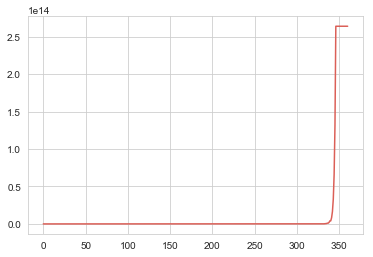

In [242]:
plt.plot(labels.T, 'k.')

In [217]:
next_inds = np.where(np.isclose(labels, i))[1]
next_locs = bo.get_locs().iloc[next_inds]

next_sub_clusters = cluster_maxdist(squareform(pdist(next_locs)), maxdist)
next_sub_clusters[next_sub_clusters > 0] = next_sub_clusters[next_sub_clusters > 0] + next_free_label
next_sub_clusters[next_sub_clusters == 0] = i

52 new observations assigned


In [224]:
next_sub_clusters.shape

(1746,)

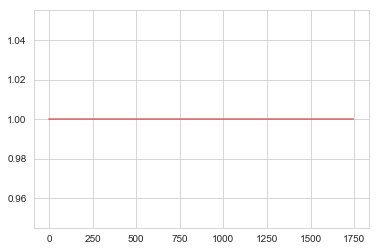

In [218]:
plt.plot(next_sub_clusters)

In [226]:
m = get_neurosynth_mask()

52 new observations assigned
51 new observations assigned
38 new observations assigned
24 new observations assigned
43 new observations assigned
6 new observations assigned
2 new observations assigned
8 new observations assigned
28 new observations assigned
18 new observations assigned
40 new observations assigned
11 new observations assigned
22 new observations assigned
1 new observations assigned
8 new observations assigned
6 new observations assigned
20 new observations assigned
1 new observations assigned
29 new observations assigned
1 new observations assigned
38 new observations assigned
37 new observations assigned
30 new observations assigned
25 new observations assigned
50 new observations assigned
12 new observations assigned
53 new observations assigned
60 new observations assigned
14 new observations assigned
4 new observations assigned
1 new observations assigned
1 new observations assigned
9 new observations assigned
2 new observations assigned
3 new observations assigned

In [228]:
labels = m.get_data()

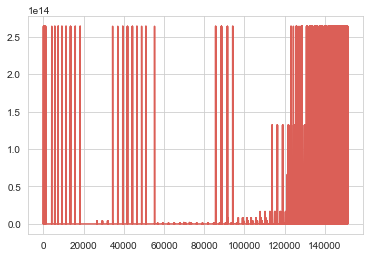

In [231]:
plt.plot(labels.T)

In [ ]:
nii_mask = se.Nifti

In [140]:
np.arange(1, 10)

array([1, 2, 3, 4, 5, 6, 7, 8, 9])

In [190]:
x = brain_mask.get_slice(loc_inds=np.where(np.isclose(brain_mask.get_data(), 2))[1]).get_locs()

In [191]:
dists = squareform(pdist(x))

In [192]:
labels = cluster_maxdist(dists, 6)

51 new observations assigned
38 new observations assigned
24 new observations assigned
43 new observations assigned
6 new observations assigned


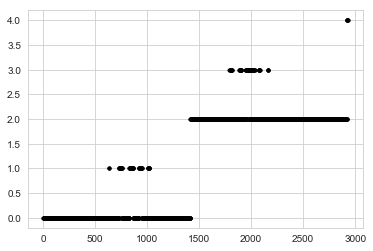

In [193]:
plt.plot(labels, 'k.')

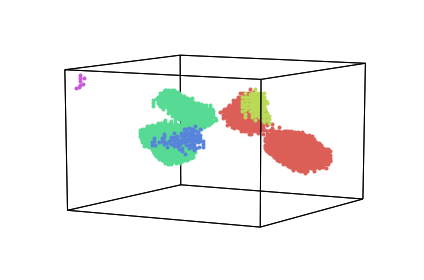

In [185]:
hyp.plot(x, '.', group=labels)

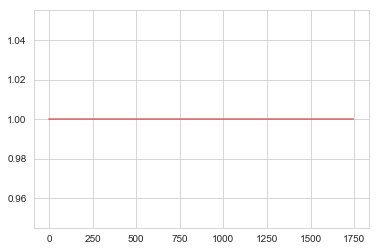

In [167]:
plt.plot(labels)

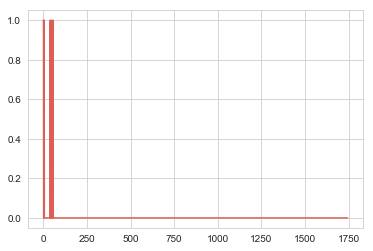

In [139]:
plt.plot(dists[0, :] <= 3)

In [120]:
brain_mask.get_locs().shape

(151349, 3)

In [129]:
labels = np.zeros(100)

In [131]:
np.any(labels == 0)

True

In [130]:
np.nonzero(labels)

(array([], dtype=int64),)

In [113]:
x = np.zeros(10)
x[3] = 1
np.nonzero(x)

(array([3]),)

In [51]:
mask = get_neurosynth_mask()

In [55]:
mask.dataobj = np.round(mask.dataobj)

AttributeError: can't set attribute

In [6]:
brain_mask = se.Brain(mask)

In [57]:
img = mask.get_data()
img = np.round(img)

In [64]:
clusters = np.unique(img)[np.unique(img) > 0]

In [66]:
q = deque(clusters.tolist())

In [68]:
np.diff

50

In [96]:
x = brain_mask.get_slice(loc_inds=np.where(np.isclose(brain_mask.get_data(), 1))[1]).get_locs()

In [102]:
x.shape

(1746, 3)

In [98]:
next_sub_clusters = hyp.cluster(x, cluster='HDBSCAN')
np.unique(next_sub_clusters)

array([-1,  0,  1])

In [80]:
np.unique(next_sub_clusters)

array([0, 1, 2])

In [107]:
dists = squareform(pdist(x))

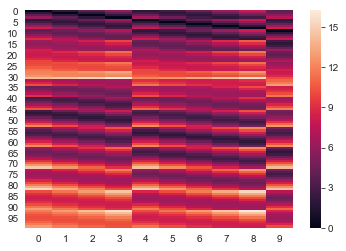

In [111]:
sns.heatmap(dists[:100, :10])

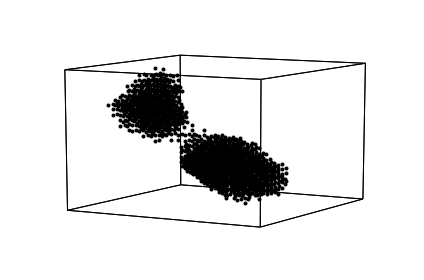

In [48]:
hyp.plot(x.loc[x.x > 0], 'k.')

In [28]:
np.where(np.isclose(brain_mask.get_data(), 1))[1]

array([54792, 54793, 54794, ..., 96490, 96491, 96513])

In [22]:
np.where(np.isclose(brain_mask.get_data(), 2))[0].shape

(2929,)

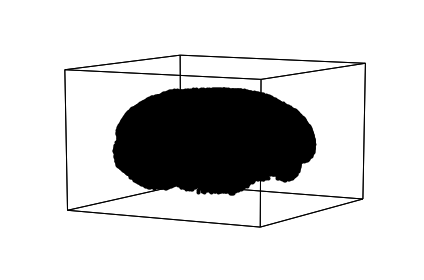

TypeError: 'NoneType' object is not subscriptable

In [13]:
list(map(lambda x: brain_mask.sl.plot_locs()[brain_mask.get_data() == x, :], np.unique(brain_mask.get_data())))

In [85]:
img = nib.load(nii_files[0])

In [87]:
type(img) == nib.nifti1.Nifti1Image

True

In [90]:
data = nii2cmu(nii_files[0])

In [94]:
nii = se.Nifti(nii_files[0])

In [99]:
x = nii.get_data()

In [102]:
brain = se.Brain(nii_files[0])

In [104]:
brain.get_data().shape

(1656, 76222)

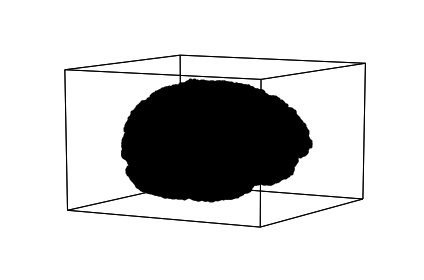

In [93]:
hyp.plot(data['R'], 'k.')

In [4]:
x = se.Nifti(nii_files[0])

In [5]:
xBrain = se.Brain(x, filter=None)

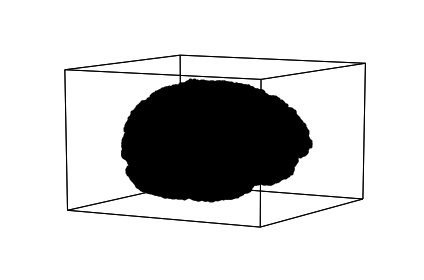

In [6]:
xBrain.plot_locs()

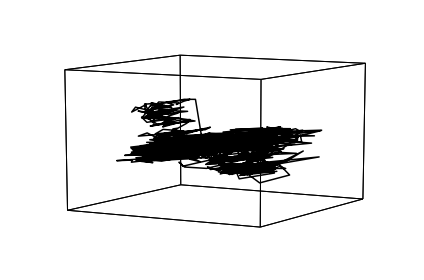

In [7]:
hyp.plot(xBrain.get_data(), 'k-')

In [8]:
miniBrain = xBrain.get_slice(loc_inds=np.arange(10))

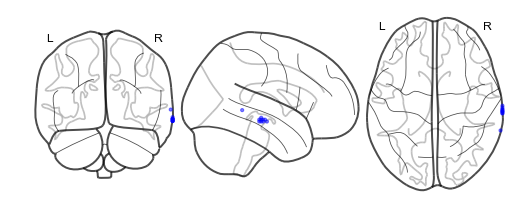

In [9]:
miniBrain.plot_locs()

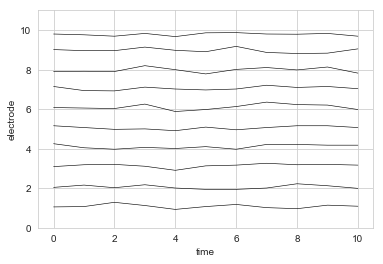

In [10]:
miniBrain.plot_data()

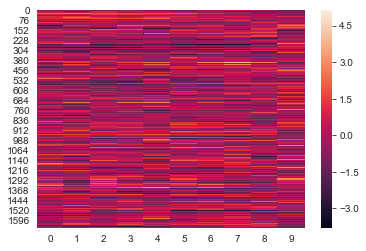

In [11]:
sns.heatmap(miniBrain.get_data())

In [12]:
mini_corrs = tc.timecorr(miniBrain.get_data())

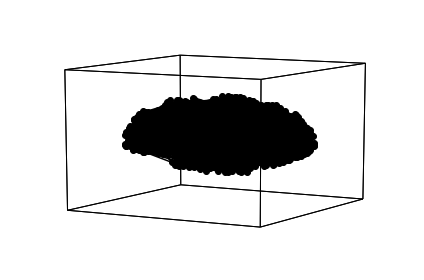

In [13]:
hyp.plot(miniBrain.get_data(), 'ko-', reduce='UMAP')

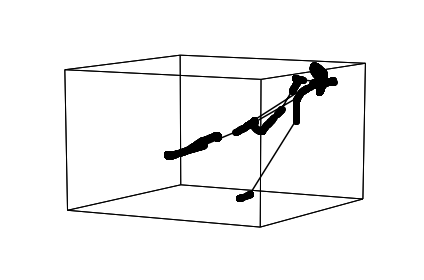

In [14]:
hyp.plot(mini_corrs, 'ko-', reduce='UMAP')

In [16]:
r0 = load(regressor_files[0])

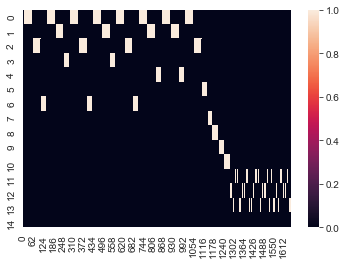

In [19]:
sns.heatmap(r0['all_regressors'])

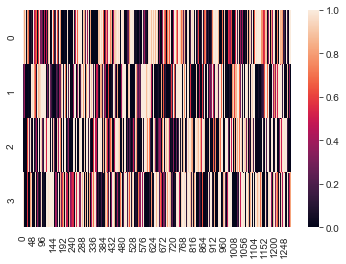

In [21]:
sns.heatmap(r0['results'])

In [25]:
# credit: https://stackoverflow.com/questions/47004506/check-if-a-numpy-array-is-sorted
@numba.jit
def is_sorted(a):
    for i in range(a.size-1):
         if a[i+1] < a[i] :
               return False
    return True

In [31]:
def ribbon(x, y, lb, ub=None, color='k', alpha='0.5'):
    #assert is_sorted(x), 'x-coordinates must be monotonically increasing'
    
    if ub is None:
        ub = lb
    h1 = plt.fill_between(x, y-lb, y+ub, color=color, alpha=alpha)
    h2 = plt.plot(x, y, color=color)
    return h1, h2

Source: https://neurolearn.readthedocs.io/en/latest/auto_examples/01_DataOperations/plot_mask.html#sphx-glr-auto-examples-01-dataoperations-plot-mask-py
```
from nltools.mask import expand_mask, collapse_mask
from nltools.data import Brain_Data
from nltools.datasets import fetch_pain

data = fetch_pain()

mask = Brain_Data('http://neurovault.org/media/images/2099/Neurosynth%20Parcellation_0.nii.gz')
mask.plot()

masked_data = data.apply_mask(mask)
masked_data.mean().plot()
```

In [115]:
def get_neurosynth_mask():
    mask = nl.Brain_Data('http://neurovault.org/media/images/2099/Neurosynth%20Parcellation_0.nii.gz')
    return mask.to_nifti()

In [116]:
nii_mask = get_neurosynth_mask()

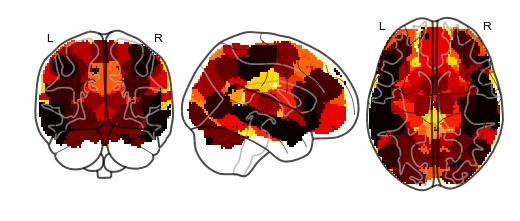

In [117]:
nl.plotting.plot_glass_brain(nii_mask)

In [81]:
np.unique(nii_mask.get_data())

array([ 0.        ,  1.        ,  2.        ,  3.        ,  4.        ,
        5.        ,  6.00000001,  6.99999999,  8.        ,  9.        ,
       10.        , 11.        , 12.        , 13.        , 14.        ,
       15.        , 16.        , 17.        , 18.00000001, 18.99999999,
       20.        , 21.        , 22.        , 23.        , 24.        ,
       25.        , 26.        , 27.        , 28.        , 29.        ,
       30.        , 31.00000001, 31.99999999, 33.        , 34.        ,
       35.        , 36.        , 37.        , 38.        , 39.        ,
       40.        , 41.        , 42.        , 43.00000001, 43.99999999,
       45.        , 46.        , 47.        , 48.        , 49.        ,
       49.99999999])

In [49]:
xNii = xBrain.to_nii()

In [50]:
nl_xBrain = nl.Brain_Data(xNii)

In [67]:
nl_xBrain2 = nl.Brain_Data(nii_files[0])

In [52]:
x_masked = nl_xBrain.extract_roi(mask)

In [ ]:
x_masked2 = nl_xBrain2.extract_roi(mask)

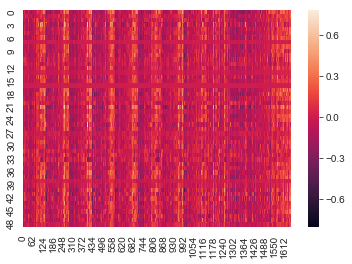

In [55]:
sns.heatmap(x_masked)

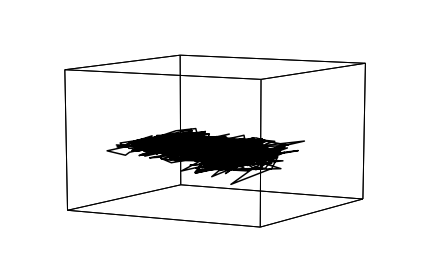

In [66]:
hyp.plot(x_masked.T, 'k-')

TypeError: '<' not supported between instances of 'str' and 'int'

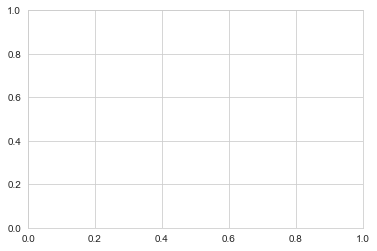

In [32]:
ribbon(np.arange(10), np.random.rand(10), np.random.randn(10))